<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_09_Segmentation_%2B_Morphology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

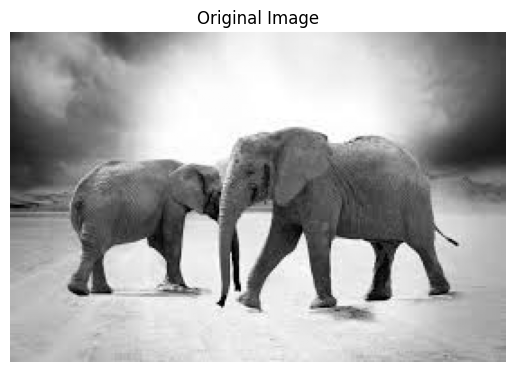

In [2]:
img = cv2.imread('images.jpg',0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

### PART 1 — Thresholding Methods

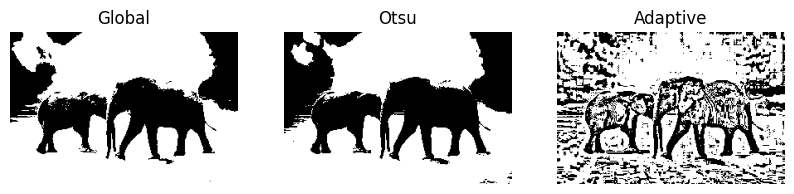

In [3]:
# Global threshold
_, global_th = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

# Otsu
_, otsu = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Adaptive
adaptive = cv2.adaptiveThreshold(img,255,
                                 cv2.ADAPTIVE_THRESH_MEAN_C,
                                 cv2.THRESH_BINARY,11,2)

plt.figure(figsize=(10,4))

titles = ["Global","Otsu","Adaptive"]
images = [global_th, otsu, adaptive]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

### PART 2 — Region Growing

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

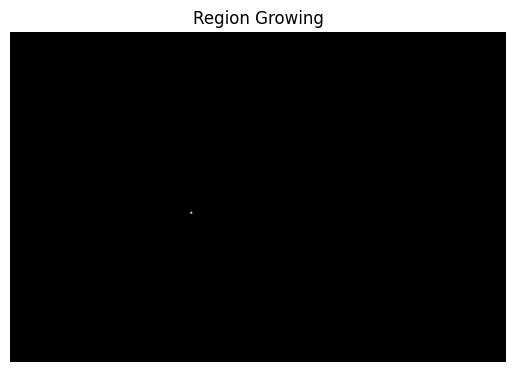

In [4]:
def region_grow(img, seed, thresh):
    rows, cols = img.shape
    visited = np.zeros_like(img)
    output = np.zeros_like(img)

    stack = [seed]

    while stack:
        x,y = stack.pop()

        if visited[x,y] == 1:
            continue

        visited[x,y] = 1
        output[x,y] = 255

        for dx in [-1,0,1]:
            for dy in [-1,0,1]:
                nx, ny = x+dx, y+dy

                if 0<=nx<rows and 0<=ny<cols:
                    if abs(int(img[nx,ny]) - int(img[x,y])) < thresh:
                        stack.append((nx,ny))

    return output

seg = region_grow(img,(100,100),10)

plt.imshow(seg, cmap='gray')
plt.title("Region Growing")
plt.axis('off')

### PART 3 — Region Splitting (Quadtree)

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

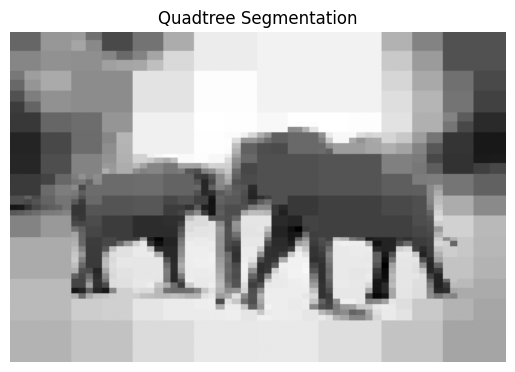

In [6]:
def split(img, thresh):
    h, w = img.shape

    if h < 4 or w < 4 or np.var(img) < thresh:
        return np.ones_like(img) * np.mean(img)

    h2, w2 = h//2, w//2

    q1 = split(img[:h2,:w2], thresh)
    q2 = split(img[:h2,w2:], thresh)
    q3 = split(img[h2:,:w2], thresh)
    q4 = split(img[h2:,w2:], thresh)

    top = np.hstack((q1,q2))
    bottom = np.hstack((q3,q4))

    return np.vstack((top,bottom))

quad = split(img,500)

plt.imshow(quad, cmap='gray')
plt.title("Quadtree Segmentation")
plt.axis('off')

### PART 4 — Morphological Operations

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

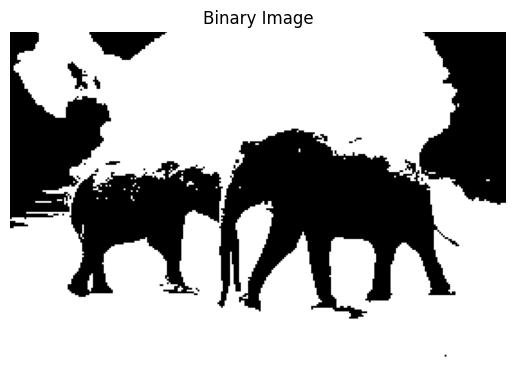

In [8]:
_, binary = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

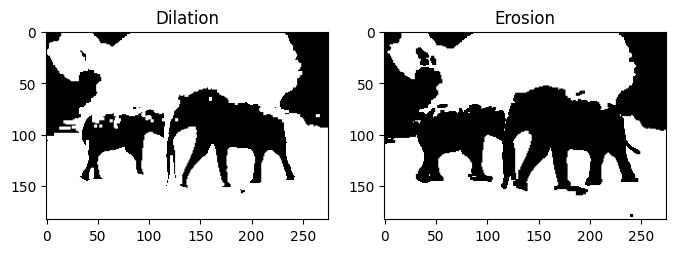

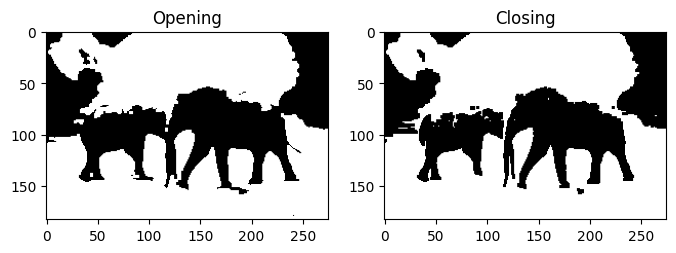

In [9]:

kernel = np.ones((3,3),np.uint8)
dilation = cv2.dilate(binary,kernel)
erosion = cv2.erode(binary,kernel)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(dilation, cmap='gray')
plt.title("Dilation")

plt.subplot(122)
plt.imshow(erosion, cmap='gray')
plt.title("Erosion")
plt.show()

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(opening, cmap='gray')
plt.title("Opening")

plt.subplot(122)
plt.imshow(closing, cmap='gray')
plt.title("Closing")
plt.show()

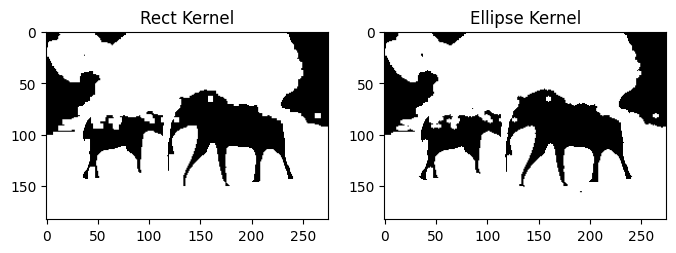

In [10]:
kernel_rect = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

rect = cv2.dilate(binary,kernel_rect)
ellipse = cv2.dilate(binary,kernel_ellipse)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(rect, cmap='gray')
plt.title("Rect Kernel")

plt.subplot(122)
plt.imshow(ellipse, cmap='gray')
plt.title("Ellipse Kernel")

plt.show()